数据预处理
1.查看数据，对数据进行缺失处理，中值填充
2.异常值检测与处理（对特征为0的进行分析）

In [1]:
import numpy as np 
import pandas as pd

In [2]:
file = pd.read_csv("D:\datas\pima\diabetes.csv")
train = file.copy()
train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
train.describe()        # 基本统计量

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Glucose  BloodPressure  SkinThickness  Insulin  BMI  为0时无意义

In [6]:
nan_col_names = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
train[nan_col_names] = train[nan_col_names].replace(0,np.nan)
train.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [7]:
train['SkinThickness_missing'] = train['SkinThickness'].apply(lambda x:1 if pd.isnull(x) else 0)
train[['SkinThickness','SkinThickness_missing','Outcome']].head(15)

,SkinThickness,SkinThickness_missing,Outcome
0,35.0,0,1
1,29.0,0,0
2,NaN,1,1
3,23.0,0,0
4,35.0,0,1
5,NaN,1,0
6,32.0,0,1
7,NaN,1,0
8,45.0,0,1
9,NaN,1,1


<ipython-input-8-120bbbe100b4>:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(x='SkinThickness_missing',hue='Outcome',data=train,palette=colors)


<Axes: xlabel='SkinThickness_missing', ylabel='count'>

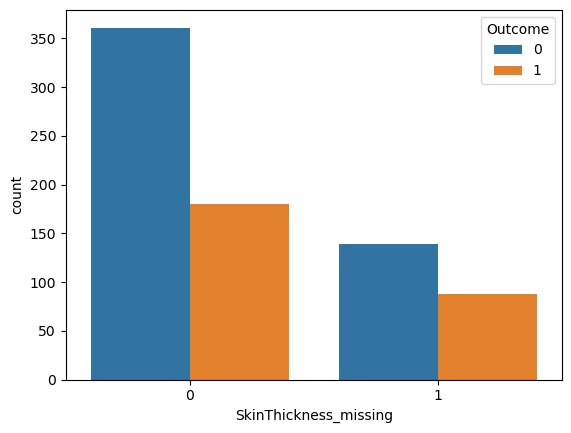

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
colors = sns.color_palette()
%matplotlib inline
# 分析特征与标记关系
sns.countplot(x='SkinThickness_missing',hue='Outcome',data=train,palette=colors)

<Axes: xlabel='Insulin_missing', ylabel='count'>

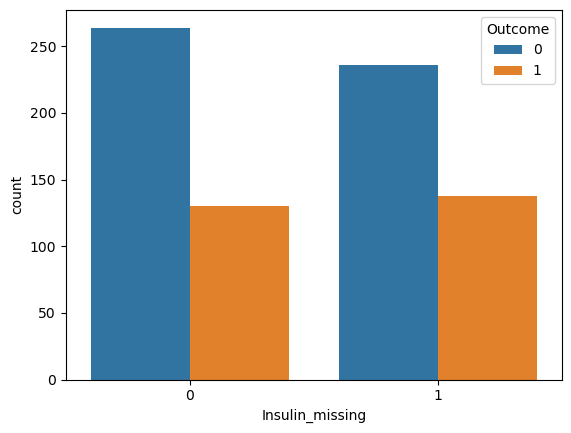

In [9]:
train['Insulin_missing'] = train['Insulin'].apply(lambda x:1 if pd.isnull(x) else 0)
train[['Insulin','Insulin_missing','Outcome']].head(10)
sns.countplot(x='Insulin_missing',hue='Outcome',data=train)

In [10]:
train.drop(['SkinThickness_missing','Insulin_missing'],axis=1,inplace=True)

In [11]:
medians = train.median()
train = train.fillna(medians)
train.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

数据标准化

In [12]:
# get labels
y_train = train['Outcome']
X_train = train.drop(['Outcome'],axis=1)

# 用于保存特征工程之后的结果
feat_names = X_train.columns

# 数据标准化
from sklearn.preprocessing import StandardScaler

# 初始化特征的标准化器
ss_X = StandardScaler()

# 分别对训练和测试数据的特征进行标准化处理
X_train = ss_X.fit_transform(X_train)
X_train

array([[ 0.63994726,  0.86604475, -0.03198993, ...,  0.16661938,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.20506583, -0.5283186 , ..., -0.85219976,
        -0.36506078, -0.19067191],
       [ 1.23388019,  2.01666174, -0.69376149, ..., -1.33250021,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 , -0.02157407, -0.03198993, ..., -0.910418  ,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.14279979, -1.02464727, ..., -0.34279019,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.94206766, -0.19743282, ..., -0.29912651,
        -0.47378505, -0.87137393]])

特征处理结果存为文件

In [13]:
X_train = pd.DataFrame(columns=feat_names,data=X_train)
train = pd.concat([X_train,y_train],axis=1)
train.to_csv('FE_pima_diabetes.csv',index = False,header=True)